# Fase 3: Estudio de Ablación

En las fases previas exploramos los datos y entrenamos nuestros modelos principales. Sin embargo, es necesario cerciorarnos que nuestro modelo sea estable.

Para resolverlo de forma científica, implementaremos un **Estudio de Ablación (*Ablation Study*)**. Evaluaremos un mismo algoritmo base (Regresión Logística) bajo tres escenarios o combinaciones de variables (*Feature Sets*):
1. **Solo Estructura:** Mide el rendimiento utilizando únicamente dimensiones físicas (altura, área, diámetro).
2. **Estructura + NDRE:** Agrega el índice de vegetación base para observar incrementos en la precisión fotosintética.
3. **Modelo Completo:** Incorpora interacciones no lineales avanzadas entre la estructura física y las firmas espectrales.

Al mantener el esquema de validación espacial por grupos (`GroupKFold`), descubriremos matemáticamente qué combinación de datos es la más robusta para producción.

In [2]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


FILE_PATH = "DATA SET CSV.csv"

df = pd.read_csv(FILE_PATH)
df = df[df["edad_aprox"].between(0, 15)].copy()

def asignar_rango_edad(x):
    if 0 <= x <= 5:
        return "0-5"
    elif 6 <= x <= 9:
        return "6-9"
    elif 10 <= x <= 15:
        return "10-15"
    else:
        return np.nan

df["edad_clase"] = df["edad_aprox"].apply(asignar_rango_edad)


df_model = df.copy()
df_model["log_area"] = np.log1p(df_model["area_m2"])
df_model["diam_max_sq"] = df_model["diam_max"] ** 2
df_model["altura_log"] = np.log1p(df_model["altura_m"])
df_model["rel_altura_diam"] = df_model["altura_m"] / (df_model["diam_max"] + 1e-6)
df_model["densidad_geom"] = df_model["area_m2"] / (df_model["diam_max"] + 1e-6)
df_model["interaccion_diam_altura"] = df_model["diam_max"] * df_model["altura_m"]
df_model["interaccion_area_ndre"] = df_model["area_m2"] * df_model["ndre_media"]
df_model["interaccion_ndre_gndvi"] = df_model["ndre_media"] * df_model["gndvi_media"]


target = "edad_clase"
group_col = "predio"

label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(df_model[target])).reset_index(drop=True)
groups = df_model[group_col].reset_index(drop=True)

print("Clases:", list(label_encoder.classes_))
print("\nDistribución de clases:")
display(df_model[target].value_counts().sort_index())
print("\nDistribución por predio y clase:")
display(pd.crosstab(df_model["predio"], df_model["edad_clase"]))


features_estructura = [
    "altura_m",
    "altura_log",
    "area_m2",
    "log_area",
    "diam_max",
    "diam_max_sq",
    "rel_altura_diam",
    "densidad_geom",
    "interaccion_diam_altura"
]

features_estructura_ndre = features_estructura + [
    "ndre_media"
]

features_completo = features_estructura + [
    "ndre_media",
    "interaccion_area_ndre",
    "interaccion_ndre_gndvi"
]

feature_sets = {
    "solo_estructura": features_estructura,
    "estructura_mas_ndre": features_estructura_ndre,
    "modelo_completo": features_completo
}

print("\nConjuntos de variables:")
for k, v in feature_sets.items():
    print(f"{k}: {v}")


def evaluar_modelo_con_feature_set(df_in, feature_list, y_encoded, groups, random_state=42):
    X = df_in[feature_list].copy()
    X = X.replace([np.inf, -np.inf], np.nan).reset_index(drop=True)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, feature_list)
        ]
    )

    n_groups = groups.nunique()
    n_splits = min(2, n_groups)
    gkf = GroupKFold(n_splits=n_splits)

    model = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("oversample", RandomOverSampler(random_state=random_state)),
        ("clf", LogisticRegression(
            C=10,
            max_iter=5000,
            class_weight="balanced",
            random_state=random_state,
            solver="lbfgs"
        ))
    ])

    y_pred = cross_val_predict(
        model,
        X,
        y_encoded,
        cv=gkf,
        groups=groups,
        method="predict",
        n_jobs=1
    )

    acc = accuracy_score(y_encoded, y_pred)
    bal_acc = balanced_accuracy_score(y_encoded, y_pred)
    f1_macro = f1_score(y_encoded, y_pred, average="macro")

    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_macro": f1_macro,
        "y_pred": y_pred,
        "model": model,
        "X": X
    }


ablation_results = []
ablation_predictions = {}

for name, feats in feature_sets.items():
    res = evaluar_modelo_con_feature_set(
        df_in=df_model,
        feature_list=feats,
        y_encoded=y,
        groups=groups,
        random_state=42
    )

    ablation_results.append({
        "modelo": name,
        "n_features": len(feats),
        "accuracy_cv": res["accuracy"],
        "balanced_accuracy_cv": res["balanced_accuracy"],
        "f1_macro_cv": res["f1_macro"]
    })

    ablation_predictions[name] = res["y_pred"]

ablation_df = pd.DataFrame(ablation_results).sort_values(
    ["balanced_accuracy_cv", "f1_macro_cv"],
    ascending=False
).reset_index(drop=True)

print("\nResultados del ablation study:")
display(ablation_df)

Clases: ['0-5', '10-15', '6-9']

Distribución de clases:


edad_clase
0-5      63
10-15    43
6-9      33
Name: count, dtype: int64


Distribución por predio y clase:


edad_clase,0-5,10-15,6-9
predio,,,
albinos,40,24,15
silvicultores,23,19,18



Conjuntos de variables:
solo_estructura: ['altura_m', 'altura_log', 'area_m2', 'log_area', 'diam_max', 'diam_max_sq', 'rel_altura_diam', 'densidad_geom', 'interaccion_diam_altura']
estructura_mas_ndre: ['altura_m', 'altura_log', 'area_m2', 'log_area', 'diam_max', 'diam_max_sq', 'rel_altura_diam', 'densidad_geom', 'interaccion_diam_altura', 'ndre_media']
modelo_completo: ['altura_m', 'altura_log', 'area_m2', 'log_area', 'diam_max', 'diam_max_sq', 'rel_altura_diam', 'densidad_geom', 'interaccion_diam_altura', 'ndre_media', 'interaccion_area_ndre', 'interaccion_ndre_gndvi']

Resultados del ablation study:


,modelo,n_features,accuracy_cv,balanced_accuracy_cv,f1_macro_cv
0,modelo_completo,12,0.812950,0.808853,0.797141
1,estructura_mas_ndre,10,0.798561,0.776682,0.772137
2,solo_estructura,9,0.769784,0.743101,0.736684


# Matrices de confusión del ablation study


===== solo_estructura =====
              precision    recall  f1-score   support

         0-5     0.9355    0.9206    0.9280        63
       10-15     0.7812    0.5814    0.6667        43
         6-9     0.5333    0.7273    0.6154        33

    accuracy                         0.7698       139
   macro avg     0.7500    0.7431    0.7367       139
weighted avg     0.7923    0.7698    0.7729       139



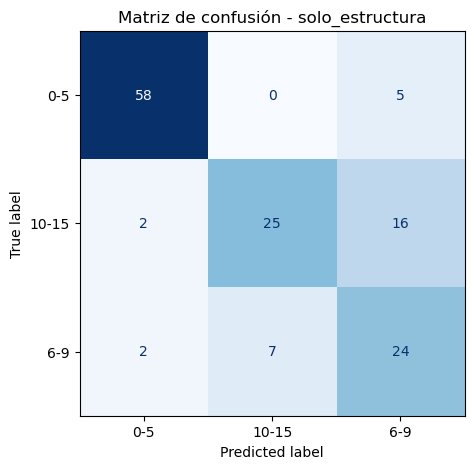


===== estructura_mas_ndre =====
              precision    recall  f1-score   support

         0-5     0.9825    0.8889    0.9333        63
       10-15     0.7619    0.7442    0.7529        43
         6-9     0.5750    0.6970    0.6301        33

    accuracy                         0.7986       139
   macro avg     0.7731    0.7767    0.7721       139
weighted avg     0.8175    0.7986    0.8055       139



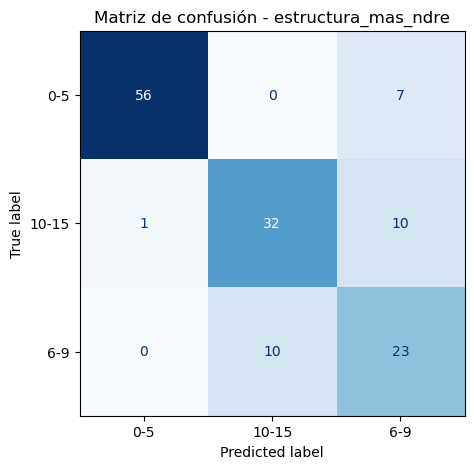


===== modelo_completo =====
              precision    recall  f1-score   support

         0-5     0.9818    0.8571    0.9153        63
       10-15     0.8611    0.7209    0.7848        43
         6-9     0.5833    0.8485    0.6914        33

    accuracy                         0.8129       139
   macro avg     0.8088    0.8089    0.7971       139
weighted avg     0.8499    0.8129    0.8217       139



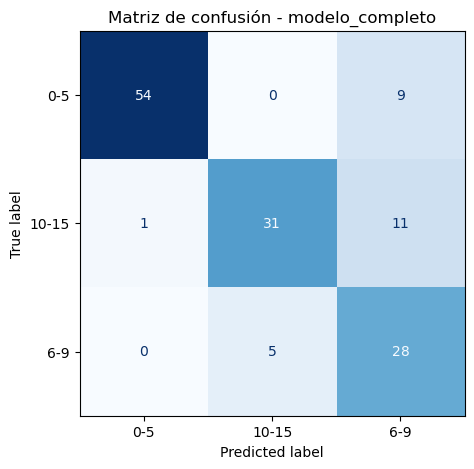

In [19]:
for name, y_pred in ablation_predictions.items():
    print(f"\n===== {name} =====")
    print(classification_report(y, y_pred, target_names=label_encoder.classes_, digits=4))

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Matriz de confusión - {name}")
    plt.show()

# Validación de estabilidad
Repetimos el mejor feature set con distintas semillas

In [21]:
# Elegir automáticamente el mejor feature set del ablation
best_feature_set_name = ablation_df.loc[0, "modelo"]
best_feature_list = feature_sets[best_feature_set_name]

print("Mejor conjunto de variables según ablation:", best_feature_set_name)
print(best_feature_list)

seeds = [7, 13, 21, 42, 77, 101, 123, 202, 303, 404]

stability_rows = []
coef_rows = []

for seed in seeds:
    X = df_model[best_feature_list].copy()
    X = X.replace([np.inf, -np.inf], np.nan).reset_index(drop=True)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, best_feature_list)
        ]
    )

    n_groups = groups.nunique()
    n_splits = min(2, n_groups)
    gkf = GroupKFold(n_splits=n_splits)

    model = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("oversample", RandomOverSampler(random_state=seed)),
        ("clf", LogisticRegression(
            C=10,
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
            solver="lbfgs"
        ))
    ])

    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=gkf,
        groups=groups,
        method="predict",
        n_jobs=1
    )

    acc = accuracy_score(y, y_pred)
    bal_acc = balanced_accuracy_score(y, y_pred)
    f1_macro = f1_score(y, y_pred, average="macro")

    stability_rows.append({
        "seed": seed,
        "accuracy_cv": acc,
        "balanced_accuracy_cv": bal_acc,
        "f1_macro_cv": f1_macro
    })

    # Ajustar en todos los datos para extraer coeficientes
    model.fit(X, y)
    clf = model.named_steps["clf"]
    coef_abs_mean = np.mean(np.abs(clf.coef_), axis=0)

    coef_dict = {"seed": seed}
    for feat, val in zip(best_feature_list, coef_abs_mean):
        coef_dict[feat] = val
    coef_rows.append(coef_dict)

stability_df = pd.DataFrame(stability_rows)
coef_df = pd.DataFrame(coef_rows)

print("\nResultados de estabilidad:")
display(stability_df)

print("\nResumen de estabilidad:")
display(stability_df.describe())

Mejor conjunto de variables según ablation: modelo_completo
['altura_m', 'altura_log', 'area_m2', 'log_area', 'diam_max', 'diam_max_sq', 'rel_altura_diam', 'densidad_geom', 'interaccion_diam_altura', 'ndre_media', 'interaccion_area_ndre', 'interaccion_ndre_gndvi']

Resultados de estabilidad:


,seed,accuracy_cv,balanced_accuracy_cv,f1_macro_cv
0,7,0.820144,0.818842,0.803996
1,13,0.820144,0.816605,0.805085
2,21,0.827338,0.824357,0.812977
3,42,0.812950,0.808853,0.797141
4,77,0.798561,0.802969,0.786513
5,101,0.834532,0.829759,0.819705
6,123,0.820144,0.814256,0.805371
7,202,0.812950,0.813551,0.798157
8,303,0.834532,0.831997,0.819832
9,404,0.841727,0.844670,0.831273



Resumen de estabilidad:


,seed,accuracy_cv,balanced_accuracy_cv,f1_macro_cv
count,10.000000,10.000000,10.000000,10.000000
mean,129.300000,0.822302,0.820586,0.808005
std,134.299044,0.012712,0.012316,0.013129
min,7.000000,0.798561,0.802969,0.786513
25%,26.250000,0.814748,0.813727,0.799617
50%,89.000000,0.820144,0.817723,0.805228
75%,182.250000,0.832734,0.828409,0.818023
max,404.000000,0.841727,0.844670,0.831273


# Gráficas de estabilidad

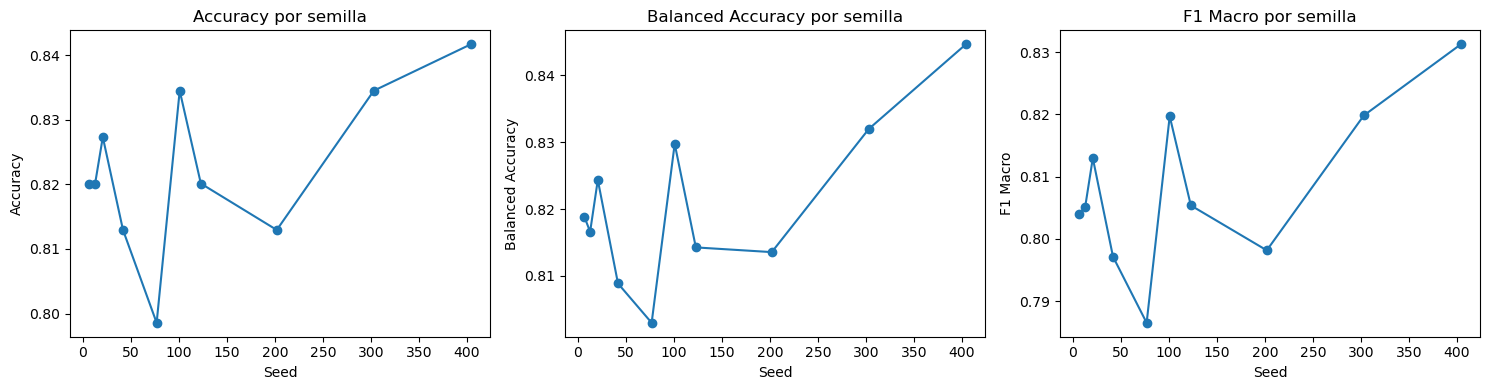

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(stability_df["seed"], stability_df["accuracy_cv"], marker="o")
axes[0].set_title("Accuracy por semilla")
axes[0].set_xlabel("Seed")
axes[0].set_ylabel("Accuracy")

axes[1].plot(stability_df["seed"], stability_df["balanced_accuracy_cv"], marker="o")
axes[1].set_title("Balanced Accuracy por semilla")
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("Balanced Accuracy")

axes[2].plot(stability_df["seed"], stability_df["f1_macro_cv"], marker="o")
axes[2].set_title("F1 Macro por semilla")
axes[2].set_xlabel("Seed")
axes[2].set_ylabel("F1 Macro")

plt.tight_layout()
plt.show()

# Estabilidad de importancia de variables

Estabilidad de relevancia de variables:


,mean,std,cv_relativo
interaccion_ndre_gndvi,3.335938,0.127662,0.038269
ndre_media,2.924195,0.233384,0.079811
area_m2,1.532457,0.183771,0.119919
altura_log,1.094853,0.117880,0.107667
rel_altura_diam,1.010138,0.062128,0.061504
densidad_geom,0.773843,0.111304,0.143832
interaccion_diam_altura,0.639831,0.209273,0.327075
altura_m,0.622206,0.146341,0.235197
log_area,0.591302,0.069459,0.117468
interaccion_area_ndre,0.429227,0.203007,0.472959


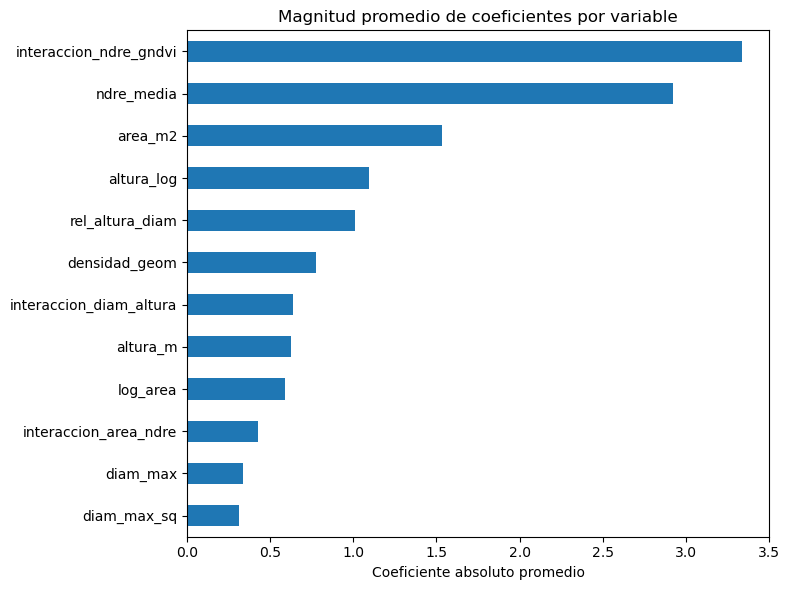

In [25]:
coef_summary = coef_df.drop(columns="seed").agg(["mean", "std"]).T
coef_summary["cv_relativo"] = coef_summary["std"] / (coef_summary["mean"] + 1e-8)
coef_summary = coef_summary.sort_values("mean", ascending=False)

print("Estabilidad de relevancia de variables:")
display(coef_summary)

plt.figure(figsize=(8, 6))
coef_summary["mean"].sort_values().plot(kind="barh")
plt.title("Magnitud promedio de coeficientes por variable")
plt.xlabel("Coeficiente absoluto promedio")
plt.tight_layout()
plt.show()

# Matriz de confusión del mejor set con semilla 42

Reporte del mejor set:

              precision    recall  f1-score   support

         0-5     0.9818    0.8571    0.9153        63
       10-15     0.8611    0.7209    0.7848        43
         6-9     0.5833    0.8485    0.6914        33

    accuracy                         0.8129       139
   macro avg     0.8088    0.8089    0.7971       139
weighted avg     0.8499    0.8129    0.8217       139



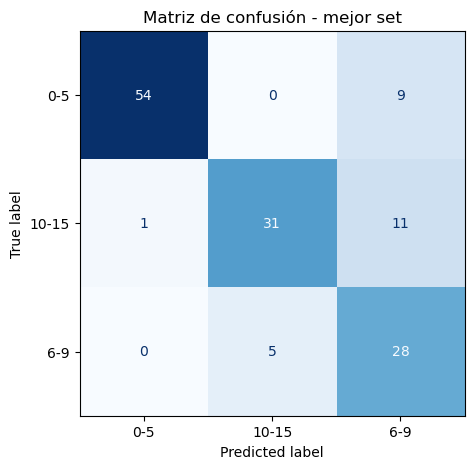

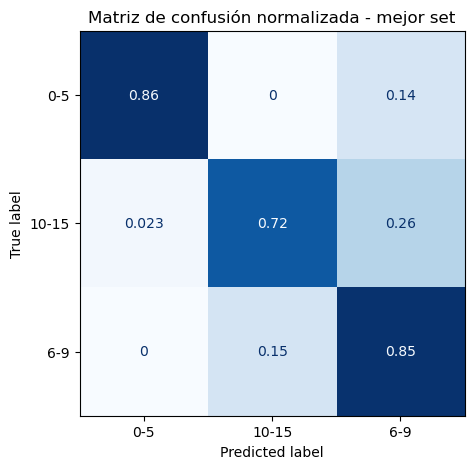

In [27]:
best_res = evaluar_modelo_con_feature_set(
    df_in=df_model,
    feature_list=best_feature_list,
    y_encoded=y,
    groups=groups,
    random_state=42
)

y_pred_best = best_res["y_pred"]

print("Reporte del mejor set:\n")
print(classification_report(y, y_pred_best, target_names=label_encoder.classes_, digits=4))

cm = confusion_matrix(y, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - mejor set")
plt.show()

cm_norm = confusion_matrix(y, y_pred_best, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión normalizada - mejor set")
plt.show()

# Desempeño por predio del mejor set

In [29]:
eval_df = pd.DataFrame({
    "predio": groups,
    "edad_clase_real": label_encoder.inverse_transform(y),
    "edad_clase_pred": label_encoder.inverse_transform(y_pred_best)
})

summary_by_predio = []

for predio_name, subdf in eval_df.groupby("predio"):
    acc = accuracy_score(subdf["edad_clase_real"], subdf["edad_clase_pred"])
    bal_acc = balanced_accuracy_score(subdf["edad_clase_real"], subdf["edad_clase_pred"])
    f1_macro = f1_score(subdf["edad_clase_real"], subdf["edad_clase_pred"], average="macro")

    summary_by_predio.append({
        "predio": predio_name,
        "n": len(subdf),
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_macro": f1_macro
    })

summary_by_predio = pd.DataFrame(summary_by_predio)

print("Desempeño por predio del mejor set:")
display(summary_by_predio)

Desempeño por predio del mejor set:


,predio,n,accuracy,balanced_accuracy,f1_macro
0,albinos,79,0.810127,0.833333,0.797138
1,silvicultores,60,0.816667,0.803119,0.801221


---

##  Fin del Pipeline Predictivo

El flujo de trabajo ha concluido con éxito. Logramos transformar los datos crudos de sensores remotos en un modelo predictivo robusto, validado espacialmente y respaldado científicamente mediante el estudio de ablación. Los entregables han sido exportados correctamente y quedan listos para su integración en sistemas GIS y la toma de decisiones estratégicas en campo.

---
**Desarrollado por:** Camilo Nihueme Chávez Flores  
*Conectando ingeniería, ciencia de datos e innovación agrícola.*  